In [1]:
from pathlib import Path
import pandas as pd
ibtracs_deaths_path = Path('/mnt/team/rapidresponse/pub/tropical-storms/data/ibtracs_deaths')

summary_df_path = ibtracs_deaths_path / "ibtracs_stage4b_pafs_admin0_with_deaths_sdi__island_20260417.csv"
# Read the data noting that 'NA' isn't NaN but 'NA'
df = pd.read_csv(summary_df_path, na_values=['<NA>'], keep_default_na=False)

In [12]:
import xarray as xr
from climada.util.constants import SYSTEM_DIR

ibtracs_file = SYSTEM_DIR / "IBTrACS.ALL.v04r01.nc"

with xr.open_dataset(ibtracs_file) as ds:
    # sid is bytes in many builds, so decode to str and strip blanks
    storm_ids = [s.decode("utf-8").strip() if isinstance(s, bytes) else str(s).strip()
                 for s in ds["sid"].values]

# optional: unique + sorted
storm_ids = sorted(set(storm_ids))

len(storm_ids), storm_ids[:10]

(13543,
 ['1842298N11080',
  '1845336N10074',
  '1848011S09079',
  '1848011S09080',
  '1848011S15057',
  '1848011S16057',
  '1848061S12075',
  '1848112S07084',
  '1848112S07444',
  '1851080S15062'])

In [13]:
tracks = TCTracks.from_ibtracs_netcdf(
    year_range=(1971, 9999), 
    provider="official"
)

2026-04-20 10:06:38,236 - climada.hazard.tc_tracks - WARNING - 1655 storm events are discarded because no valid wind/pressure values have been found: 1971005S18039, 1971008N07139, 1971008N08143, 1971015S12100, 1971017S11059, ...
2026-04-20 10:06:38,277 - climada.hazard.tc_tracks - WARNING - 34 storm events are discarded because only one valid timestep has been found: 1971142N12267, 1971188N12254, 1971202N16256, 1971241N12252, 1971330N10260, ...


In [14]:
tracks

In [2]:
path = Path('/mnt/team/rapidresponse/pub/tropical-storms/climada/output/ibtracs_stage4b_pafs_admin0_with_deaths/ibtracs/official/historical')
year = 1988
# find all folders in path/year
basins = [f.name for f in (path / str(year)).iterdir() if f.is_dir()]
# Find all files in all basin folders
storm_files = []

for basin in basins:
    basin_path = path / str(year) / basin / 'storm_paf'
    basin_files = [f for f in basin_path.iterdir() if f.is_file() and f.suffix == '.parquet']
    for basin_file in basin_files:
        # format is storm_{storm_id}_{basin}_ibtracs_official_historical_{year}.parquet'
        # Extract storm_id, basin, and year from filename and save these three quantities into a dataframe
        fname = basin_file.stem
        parts = fname.split('_')
        storm_id = parts[1]
        basin_name = parts[2]
        file_year = parts[-1]
        df = pd.DataFrame({'storm_id': [storm_id], 'basin': [basin_name], 'year': [file_year]})
        storm_files.append(df)
storm_files = pd.concat(storm_files, ignore_index=True)

In [7]:
track = TCTracks.from_ibtracs_netcdf(
        storm_id="1988285N09318"
    )

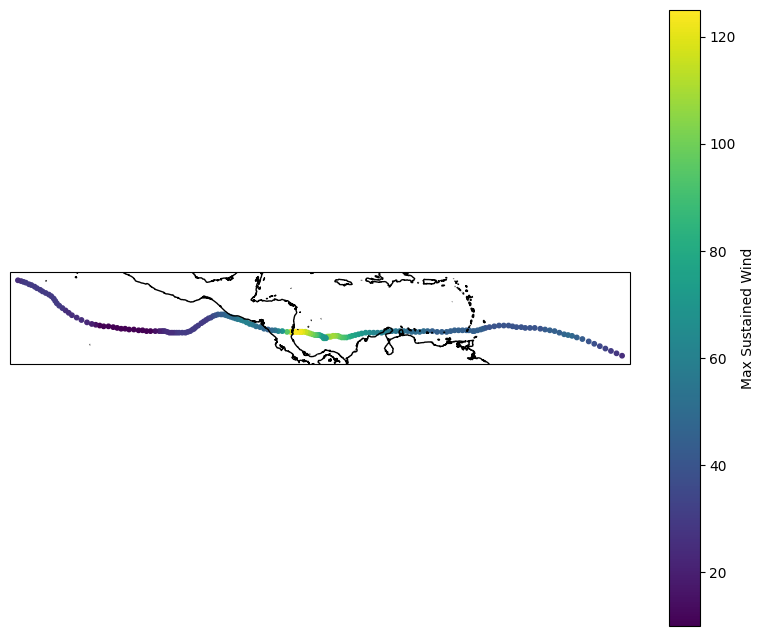

In [16]:
# Plot one storm track with point color/size based on max sustained wind
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# TCTracks.from_ibtracs_netcdf returns a TCTracks container; select the first storm
storm = track.data[0] if hasattr(track, "data") else track

lats = np.asarray(storm["lat"].values, dtype=float).ravel()
lons = np.asarray(storm["lon"].values, dtype=float).ravel()
winds = np.asarray(storm["max_sustained_wind"].values, dtype=float).ravel()

# Keep only rows where all required values are finite
valid = np.isfinite(lats) & np.isfinite(lons) & np.isfinite(winds)
lats = lats[valid]
lons = lons[valid]
winds = winds[valid]

if lats.size == 0 or lons.size == 0:
    raise ValueError("No valid lat/lon points found for this storm.")

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_extent([lons.min() - 1, lons.max() + 1, lats.min() - 1, lats.max() + 1], crs=ccrs.PlateCarree())

# Ensure marker sizes are visible and non-zero
sizes = np.clip(winds * 0.1, 10, None)
sc = ax.scatter(lons, lats, c=winds, s=sizes, cmap="viridis", transform=ccrs.PlateCarree())
plt.colorbar(sc, label="Max Sustained Wind")
plt.show()

In [3]:
from climada.hazard import TCTracks
def get_ibtracs_storm(
    basin: str,
    storm_id: str,
):

    year = int(storm_id[:4])
    year_range = (year, year)

    tracs = TCTracks.from_ibtracs_netcdf(
        provider="official",
        year_range=year_range,
        basin=basin
    )

    storms = tracs.data  # list of TCTrack objects

    # find matching storm
    matched_id = [s for s in storms if s.sid == storm_id]

    if len(matched_id) == 0:
        raise ValueError(f"No storm found with id {storm_id}")

    storm_ds = matched_id[0]

    return storm_ds

In [4]:
get_ibtracs_storm("NA", "1988285N09318")

IBTrACS.ALL.v04r01.nc: 23.3MB [00:02, 7.80MB/s]                            


2026-04-20 09:46:49,008 - climada.hazard.tc_tracks - WARNING - 7 storm events are discarded because no valid wind/pressure values have been found: 1988153N20275, 1988226N25286, 1988234N13299, 1988234N13339, 1988248N28267, ...


<xarray.Dataset> Size: 10kB
Dimensions:                 (time: 185)
Coordinates:
  * time                    (time) datetime64[ns] 1kB 1988-10-10T18:00:00 ......
    lat                     (time) float32 740B 8.9 9.2 9.5 ... 18.2 18.3 18.4
    lon                     (time) float32 740B -42.2 -42.9 ... -117.9 -118.3
Data variables:
    radius_max_wind         (time) float32 740B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    radius_oci              (time) float32 740B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    max_sustained_wind      (time) float32 740B 25.0 27.5 30.0 ... 27.5 25.0
    central_pressure        (time) float32 740B 1.01e+03 1.009e+03 ... 1.01e+03
    environmental_pressure  (time) float64 1kB 1.01e+03 1.01e+03 ... 1.01e+03
    time_step               (time) float64 1kB 3.0 3.0 3.0 3.0 ... 3.0 3.0 3.0
    basin                   (time) <U2 1kB 'NA' 'NA' 'NA' ... 'EP' 'EP' 'EP'
Attributes:
    max_sustained_wind_unit:  kn
    central_pressure_unit:    mb
    orig_event_flag:          True
    data_provider:            ibtracs_official
    category:                 4
    name:                     JOAN:MIRIAM
    sid:                      1988285N09318
    id_no:                    1988285009318.0

In [5]:
get_ibtracs_storm("EP", "1988285N09318")

2026-04-20 09:47:11,786 - climada.hazard.tc_tracks - WARNING - 8 storm events are discarded because no valid wind/pressure values have been found: 1988168N13248, 1988184N19251, 1988211N18230, 1988227N18250, 1988240N15248, ...


<xarray.Dataset> Size: 10kB
Dimensions:                 (time: 185)
Coordinates:
  * time                    (time) datetime64[ns] 1kB 1988-10-10T18:00:00 ......
    lat                     (time) float32 740B 8.9 9.2 9.5 ... 18.2 18.3 18.4
    lon                     (time) float32 740B -42.2 -42.9 ... -117.9 -118.3
Data variables:
    radius_max_wind         (time) float32 740B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    radius_oci              (time) float32 740B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    max_sustained_wind      (time) float32 740B 25.0 27.5 30.0 ... 27.5 25.0
    central_pressure        (time) float32 740B 1.01e+03 1.009e+03 ... 1.01e+03
    environmental_pressure  (time) float64 1kB 1.01e+03 1.01e+03 ... 1.01e+03
    time_step               (time) float64 1kB 3.0 3.0 3.0 3.0 ... 3.0 3.0 3.0
    basin                   (time) <U2 1kB 'NA' 'NA' 'NA' ... 'EP' 'EP' 'EP'
Attributes:
    max_sustained_wind_unit:  kn
    central_pressure_unit:    mb
    orig_event_flag:          True
    data_provider:            ibtracs_official
    category:                 4
    name:                     JOAN:MIRIAM
    sid:                      1988285N09318
    id_no:                    1988285009318.0

In [33]:
storm_files[storm_files['storm_id'] == '1988285N09318']

,storm_id,basin,year
23,1988285N09318,EP,1988
31,1988285N09318,NA,1988


In [25]:
def get_ibtracs_storm(
    basin: str,
    storm_id: str,
):

    year = int(storm_id[:4])
    year_range = (year, year)

    tracs = TCTracks.from_ibtracs_netcdf(
        provider="official",
        year_range=year_range,
        basin=basin
    )

    storms = tracs.data  # list of TCTrack objects

    # find matching storm
    matched_id = [s for s in storms if s.sid == storm_id]

    if len(matched_id) == 0:
        raise ValueError(f"No storm found with id {storm_id}")

    storm_ds = matched_id[0]

    return storm_ds

['SI', 'WP', 'SP', 'EP', 'NA']

In [ ]:
def get_ibtracs_storm(
    basin: str,
    storm_id: str,
):

    year = int(storm_id[:4])
    year_range = (year, year)

    tracs = TCTracks.from_ibtracs_netcdf(
        provider="official",
        year_range=year_range,
        basin=basin
    )

    storms = tracs.data  # list of TCTrack objects

    # find matching storm
    matched_id = [s for s in storms if s.sid == storm_id]

    if len(matched_id) == 0:
        raise ValueError(f"No storm found with id {storm_id}")

    storm_ds = matched_id[0]

    return storm_ds

In [22]:
storm_dfs = []
storm_id = '1988285N09318'
tmp_df = df[df['storm_id'] == storm_id]
tmp_year = tmp_df['year'].unique()[0]
tmp_folder = ibtracs_deaths_path / tmp_year.astype(str)
tmp_basins = tmp_df['basins'].unique()
tmp_basins = pd.array([b for b in tmp_basins if ',' in b], dtype="string")
tmp_basins = tmp_basins.unique()[0]
tmp_basins_to_check = tmp_basins.split(',')
print(f"Storm ID: {storm_id}, Basins with issues: {tmp_basins_to_check}")
correct_basin = None
for tmp_basin_to_check in tmp_basins_to_check:
    tmp_csv = pd.read_csv(tmp_folder / f"ibtracks_{tmp_basin_to_check}_historical.csv")
    storm_dfs.append(tmp_csv)
    if storm_id in tmp_csv['storm_id'].values:
        correct_basin = tmp_basin_to_check
        print(f"Storm ID: {storm_id} found in basin: {correct_basin}")
if correct_basin is None:
    print(f"Storm ID: {storm_id} not found in any of the basins: {tmp_basins_to_check}")

storm_dfs = pd.concat(storm_dfs, ignore_index=True)
storm_df = storm_dfs[storm_dfs['storm_id'] == storm_id]

Storm ID: 1988285N09318, Basins with issues: ['EP', 'NA']
Storm ID: 1988285N09318 found in basin: EP
Storm ID: 1988285N09318 found in basin: NA


In [23]:
storm_df

,storm_id,year,start_date,end_date,location_id,max_wind_speed,pop_total,exposed_population,total_deaths
16,1988285N09318,1988,1988-10-10,1988-11-02,126,43.574988,3.052996e+06,5.960789e+06,28
17,1988285N09318,1988,1988-10-10,1988-11-02,127,30.765154,5.654778e+06,1.062515e+08,0
18,1988285N09318,1988,1988-10-10,1988-11-02,128,30.481423,1.085042e+07,1.429973e+08,0
19,1988285N09318,1988,1988-10-10,1988-11-02,129,30.584087,9.336350e+06,8.931849e+07,0
20,1988285N09318,1988,1988-10-10,1988-11-02,131,63.239176,5.652787e+06,5.128384e+07,130
21,1988285N09318,1988,1988-10-10,1988-11-02,132,24.261097,2.365044e+06,9.187196e+06,30
22,1988285N09318,1988,1988-10-10,1988-11-02,133,27.223577,2.504129e+07,6.428660e+06,0
23,1988285N09318,1988,1988-10-10,1988-11-02,300,21.359859,6.401558e+04,7.664824e+05,0
24,1988285N09318,1988,1988-10-10,1988-11-02,4649,23.390207,9.715578e+06,8.552057e+07,0
25,1988285N09318,1988,1988-10-10,1988-11-02,54154,26.094692,1.794290e+06,3.670583e+07,0


In [19]:
issue_rows = df[df['basins'].str.contains(',')]
issue_storms = issue_rows['storm_id'].unique()
for storm_id in issue_storms:
    tmp_df = df[df['storm_id'] == storm_id]
    tmp_year = tmp_df['year'].unique()[0]
    tmp_folder = ibtracs_deaths_path / tmp_year.astype(str)
    tmp_basins = tmp_df['basins'].unique()
    tmp_basins = pd.array([b for b in tmp_basins if ',' in b], dtype="string")
    tmp_basins = tmp_basins.unique()[0]
    tmp_basins_to_check = tmp_basins.split(',')
    print(f"Storm ID: {storm_id}, Basins with issues: {tmp_basins_to_check}")
    correct_basin = None
    for tmp_basin_to_check in tmp_basins_to_check:
        tmp_csv = pd.read_csv(tmp_folder / f"ibtracks_{tmp_basin_to_check}_historical.csv")
        if storm_id in tmp_csv['storm_id'].values:
            correct_basin = tmp_basin_to_check
            print(f"Storm ID: {storm_id} found in basin: {correct_basin}")
    if correct_basin is None:
        print(f"Storm ID: {storm_id} not found in any of the basins: {tmp_basins_to_check}")

Storm ID: 1997298N06140, Basins with issues: ['NI', 'WP']
Storm ID: 1997298N06140 found in basin: NI
Storm ID: 1997298N06140 found in basin: WP
Storm ID: 2010247N15266, Basins with issues: ['EP', 'NA']
Storm ID: 2010247N15266 found in basin: EP
Storm ID: 2010247N15266 found in basin: NA
Storm ID: 1988245N20269, Basins with issues: ['EP', 'NA']
Storm ID: 1988245N20269 found in basin: EP
Storm ID: 1988245N20269 found in basin: NA
Storm ID: 1988285N09318, Basins with issues: ['EP', 'NA']
Storm ID: 1988285N09318 found in basin: EP
Storm ID: 1988285N09318 found in basin: NA
Storm ID: 1990216N13281, Basins with issues: ['EP', 'NA']
Storm ID: 1990216N13281 found in basin: EP
Storm ID: 1990216N13281 found in basin: NA
Storm ID: 1996232N17280, Basins with issues: ['EP', 'NA']
Storm ID: 1996232N17280 found in basin: EP
Storm ID: 1996232N17280 found in basin: NA
Storm ID: 2003271N18275, Basins with issues: ['EP', 'NA']
Storm ID: 2003271N18275 found in basin: EP
Storm ID: 2003271N18275 found in ba

In [12]:
issue_rows

,Unnamed: 0,storm_id,location_id,year,total_deaths,exposed_population,pop_total,max_wind_speed,basins,sdi,...,developed,start_date,end_date,date_inserted,last_updated,last_updated_by,last_updated_action,lancet_label,who_label,is_island
1505,1505,1997298N06140,20,1997,3682.0,1.088951e+07,7.702207e+07,29.367002,"NI,WP",0.474137,...,0,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,Viet Nam,Socialist Republic of Viet Nam,0.0
1686,1686,2010247N15266,102,2010,9.0,2.871307e+06,3.093120e+08,25.098202,"EP,NA",0.829490,...,1,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,USA,United States of America,0.0
1913,1913,1988245N20269,130,1988,0.0,1.473579e+07,8.217159e+07,28.054857,"EP,NA",0.500666,...,0,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,Mexico,United Mexican States,0.0
1917,1917,1988285N09318,130,1988,240.0,6.517098e+05,8.217159e+07,21.252426,"EP,NA",0.500666,...,0,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,Mexico,United Mexican States,0.0
1926,1926,1990216N13281,130,1990,0.0,9.321947e+06,8.539100e+07,33.321739,"EP,NA",0.509330,...,0,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,Mexico,United Mexican States,0.0
1964,1964,1996232N17280,130,1996,2.0,4.509821e+06,9.555690e+07,27.995270,"EP,NA",0.541145,...,0,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,Mexico,United Mexican States,0.0
1999,1999,2003271N18275,130,2003,2.0,3.873368e+06,1.051331e+08,22.635542,"EP,NA",0.581420,...,0,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,Mexico,United Mexican States,0.0
2030,2030,2010247N15266,130,2010,0.0,9.603674e+05,1.148813e+08,29.000298,"EP,NA",0.603159,...,0,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,Mexico,United Mexican States,0.0
2046,2046,2013149N14264,130,2013,0.0,3.298276e+06,1.194955e+08,30.416292,"EP,NA",0.618372,...,0,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,Mexico,United Mexican States,0.0
2103,2103,1988285N09318,133,1988,0.0,1.861824e+05,1.791797e+07,21.094700,"EP,NA",0.510331,...,0,2026-01-07 12:37:30,,2026-01-07 12:37:30,2026-01-07 12:37:30,cathc19,INSERT,Venezuela,Bolivarian Republic of Venezuela,0.0


In [3]:
df['exposed_per_capita'] = df['exposed_population'] / df['pop_total']
df['exposed_population'].max()

np.float64(173393360.0)

In [9]:
df[df['location_id'] == 102]['basins']

1575    NA
1576    WP
1577    NA
1578    NA
1579    NA
        ..
1737    NA
1738    NA
1739    NA
1740    NA
1741    NA
Name: basins, Length: 167, dtype: str

In [24]:
df[(df['parent_id'] == 163) & (df['year'] == 2011)]

,Unnamed: 0,storm_id,year,start_date_x,end_date_x,location_id,max_wind_speed,pop_total,exposed_population,total_deaths,...,last_updated,last_updated_by,last_updated_action,lancet_label,who_label,is_island,sdi_ln,wind_mph,storm_category,log_exposed_population
7334,7334,2011167N22089,2011,2011-06-16,2011-06-22,4844,24.072541,1.746992e+08,1.213888e+08,0,...,2026-01-07 12:37:30,cathc19,INSERT,Bihar,NaN,0.0,-1.034984,53.850273,Tropical Storm,18.614509
7335,7335,2011203N24085,2011,2011-07-22,2011-07-23,4844,22.729811,1.746992e+08,3.344823e+07,0,...,2026-01-07 12:37:30,cathc19,INSERT,Bihar,NaN,0.0,-1.034984,50.846587,Tropical Storm,17.325509
7367,7367,2011167N22089,2011,2011-06-16,2011-06-22,4846,24.673973,5.671615e+07,6.908050e+07,0,...,2026-01-07 12:37:30,cathc19,INSERT,Chhattisgarh,NaN,0.0,-0.949031,55.195678,Tropical Storm,18.050783
7368,7368,2011203N24085,2011,2011-07-22,2011-07-23,4846,20.639986,5.671615e+07,4.289955e+06,0,...,2026-01-07 12:37:30,cathc19,INSERT,Chhattisgarh,NaN,0.0,-0.949031,46.171648,Tropical Storm,15.271787
7416,7416,2011167N22089,2011,2011-06-16,2011-06-22,4855,27.650182,9.942733e+07,2.074154e+09,0,...,2026-01-07 12:37:30,cathc19,INSERT,Jharkhand,NaN,0.0,-0.934865,61.853457,Tropical Storm,21.452819
7417,7417,2011203N24085,2011,2011-07-22,2011-07-23,4855,22.729811,9.942733e+07,4.720078e+07,0,...,2026-01-07 12:37:30,cathc19,INSERT,Jharkhand,NaN,0.0,-0.934865,50.846587,Tropical Storm,17.669921
7458,7458,2011167N22089,2011,2011-06-16,2011-06-22,4859,21.802992,1.957998e+08,2.643527e+08,0,...,2026-01-07 12:37:30,cathc19,INSERT,Madhya Pradesh,NaN,0.0,-0.974818,48.773294,Tropical Storm,19.392795
7459,7459,2011203N24085,2011,2011-07-22,2011-07-23,4859,23.184006,1.957998e+08,5.631550e+07,0,...,2026-01-07 12:37:30,cathc19,INSERT,Madhya Pradesh,NaN,0.0,-0.974818,51.862622,Tropical Storm,17.846480
7516,7516,2011167N22089,2011,2011-06-16,2011-06-22,4865,22.776374,7.082619e+07,1.880561e+08,0,...,2026-01-07 12:37:30,cathc19,INSERT,Odisha,NaN,0.0,-0.875449,50.950749,Tropical Storm,19.052251
7552,7552,2011167N22089,2011,2011-06-16,2011-06-22,4873,24.673973,2.975295e+08,4.257985e+08,0,...,2026-01-07 12:37:30,cathc19,INSERT,Uttar Pradesh,NaN,0.0,-0.912267,55.195678,Tropical Storm,19.869477


In [22]:
df.columns

Index(['Unnamed: 0', 'storm_id', 'year', 'start_date_x', 'end_date_x',
       'location_id', 'max_wind_speed', 'pop_total', 'exposed_population',
       'total_deaths', 'data_year', 'basin', 'sdi', 'ln_total_deaths',
       'deaths_rate', 'ln_death_rate', 'ln_death_rate_pop_weighted',
       'exists_deaths', 'ln_exists_deaths', 'location_set_version_id',
       'location_set_id', 'parent_id', 'path_to_top_parent', 'level',
       'is_estimate', 'most_detailed', 'sort_order', 'location_name',
       'location_ascii_name', 'location_name_short', 'location_name_medium',
       'location_type_id', 'location_type', 'map_id', 'super_region_id',
       'super_region_name', 'region_id', 'region_name', 'ihme_loc_id',
       'local_id', 'developed', 'start_date_y', 'end_date_y', 'date_inserted',
       'last_updated', 'last_updated_by', 'last_updated_action',
       'lancet_label', 'who_label', 'is_island', 'sdi_ln', 'wind_mph',
       'storm_category', 'log_exposed_population'],
      dtype='st

In [14]:
nosdi = df[df['sdi'].isna()]
yessdi = df[df['sdi'].notna()]
nosdi[nosdi['level'] == 3]['year'].describe()

count      30.0
mean     2024.0
std         0.0
min      2024.0
25%      2024.0
50%      2024.0
75%      2024.0
max      2024.0
Name: year, dtype: float64

In [11]:
yessdi['level'].describe()

count    3878.000000
mean        3.632543
std         0.482175
min         3.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: level, dtype: float64

In [9]:
df

,Unnamed: 0,storm_id,year,start_date_x,end_date_x,location_id,max_wind_speed,pop_total,exposed_population,total_deaths,...,last_updated,last_updated_by,last_updated_action,lancet_label,who_label,is_island,sdi_ln,wind_mph,storm_category,log_exposed_population
0,0,1980001S13173,1980,1980-01-02,1980-01-06,22,38.104884,7.472469e+07,9.563711e+05,0,...,2026-01-07 12:37:30,cathc19,INSERT,Fiji,Republic of Fiji,1.0,-0.730256,85.240625,Category 1,13.770902
1,1,1980081S12170,1980,1980-03-22,1980-03-27,22,31.793752,7.472469e+07,3.034474e+05,18,...,2026-01-07 12:37:30,cathc19,INSERT,Fiji,Republic of Fiji,1.0,-0.730256,71.122622,Tropical Storm,12.622967
2,2,1981011S12185,1981,1981-01-11,1981-01-17,22,40.924146,7.665518e+07,1.261257e+07,0,...,2026-01-07 12:37:30,cathc19,INSERT,Fiji,Republic of Fiji,1.0,-0.720513,91.547315,Category 1,16.350204
3,3,1982024S18166,1982,1982-01-24,1982-02-06,22,39.380829,7.860501e+07,2.264775e+06,0,...,2026-01-07 12:37:30,cathc19,INSERT,Fiji,Republic of Fiji,1.0,-0.719205,88.094913,Category 1,14.632986
4,4,1983054S15179,1983,1983-02-23,1983-03-06,22,62.537863,8.057710e+07,1.855014e+07,9,...,2026-01-07 12:37:30,cathc19,INSERT,Fiji,Republic of Fiji,1.0,-0.718729,139.897200,Category 4,16.735988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9540,9540,2023292N11063,2023,2023-10-20,2023-10-24,157,42.877912,4.028118e+07,1.387604e+07,7,...,2026-01-07 12:37:30,cathc19,INSERT,Yemen,Republic of Yemen,0.0,-0.800340,95.917890,Category 1,16.445674
9541,9541,2017354N08134,2017,2017-12-20,2017-12-25,13,27.895597,4.659332e+07,9.264920e+05,0,...,2026-01-07 12:37:30,cathc19,INSERT,Malaysia,Malaysia,0.0,-0.380708,62.402450,Tropical Storm,13.739162
9542,9542,2017354N08134,2017,2017-12-20,2017-12-25,53609,33.445004,4.720440e+05,1.040896e+05,0,...,2026-01-07 12:37:30,cathc19,INSERT,Tawi-Tawi,NaN,1.0,NaN,74.816474,Category 1,11.553017
9543,9543,2018226N23128,2018,2018-08-15,2018-08-17,502,20.771355,1.638777e+08,1.898371e+07,0,...,2026-01-07 12:37:30,cathc19,INSERT,Henan,NaN,0.0,-0.460923,46.465521,Tropical Storm,16.759092


In [ ]:
df['death_rate'] = df['deaths'] / df['exposed']
df['log_exposed'] = np.log(df['exposed'])
df[['exposed', 'log_exposed', 'deaths', 'death_rate']].describe()